<a href="https://colab.research.google.com/github/fcoliveira-utfpr/relacoes_fisicas_ambiente/blob/main/codigos_python/aula_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 03 · Notebook auxiliar: MZA-FAO passo a passo

**Disciplina:** Relações Físicas do Ambiente Agrícola

Exemplo completo do Modelo da Zona Agroecológica da FAO para **um local** e **uma safra**, com dados diários do BR-DWGD (Xavier et al., 2022):

1. Extração dos dados da safra no ponto.
2. Variáveis diárias: Qo, N, ETo (Penman-Monteith FAO-56), kc, profundidade radicular e CAD.
3. Agregação decendial.
4. Produtividade potencial (PPBp → PPf).
5. Balanço hídrico da cultura (Thornthwaite & Mather).
6. Produtividade atingível pelo **produtório**, com a redução de cada fase.
7. Eficiência climática e comparação com a penalização em etapa única.

O local, a cultura e a data de semeadura são ajustáveis na seção 2. Os parâmetros das culturas são os da Tabela 5 do roteiro da Aula 03.

# 1. Bibliotecas e autenticação
___

In [1]:
!pip install -q agrometeorologiapy

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ee
import agrometeorologiapy as amp

ID_PROJETO = 'fcoliveira'
ee.Authenticate()
ee.Initialize(project=ID_PROJETO)
print('Earth Engine conectado ao projeto:', ID_PROJETO)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


Earth Engine conectado ao projeto: fcoliveira


# 2. Configurações
___

In [2]:
# ================== LOCAL, CULTURA E SAFRA (AJUSTÁVEIS) ==================
NOME_LOCAL = 'Medianeira-PR'
LON, LAT   = -54.094, -25.295      # coordenadas da sede (IBGE)
ALTITUDE   = 402                   # m
CULTURA    = 'soja'                # soja, milho1, milho2, trigo, feijao, girassol
SEMEADURA  = '2023-10-01'          # data de semeadura (AAAA-MM-DD)
AD_SOLO    = 1.0                   # água disponível do solo (mm/cm)
# =========================================================================

PASTA_FIG, PASTA_DADOS = 'figuras', 'dados'
os.makedirs(PASTA_FIG, exist_ok=True)
os.makedirs(PASTA_DADOS, exist_ok=True)

plt.rcParams.update({'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 110})


def fmt(v):
    """Número inteiro com ponto como separador de milhar (padrão brasileiro)."""
    return f'{v:,.0f}'.replace(',', '.')


def salvar(fig, nome):
    caminho = os.path.join(PASTA_FIG, nome)
    fig.savefig(caminho, dpi=200, bbox_inches='tight')
    print('Figura salva em:', caminho)

## 2.1 Parâmetros das culturas

As quatro fases seguem Doorenbos & Kassam: **vegetativa**, **floração**, **formação da produção** e **maturação**. A fase vegetativa é dividida em período inicial (`ini`) e de desenvolvimento (`dev`) para montar a curva de kc da FAO-56:

- `ini`: kc constante igual a Kc ini;
- `dev`: kc cresce linearmente de Kc ini até Kc mid;
- floração e formação da produção: kc constante igual a Kc mid;
- maturação: kc decresce linearmente de Kc mid até Kc end.

A profundidade radicular cresce linearmente de 0,2 m na semeadura até Zr máx no fim da fase vegetativa.

In [3]:
CULTURAS = {
    #             rota   ini dev flor form mat   Kc ini/mid/end       ky por fase              IAF   Cc    U%   Zr máx  ky ciclo
    'soja':     dict(rota='C3', ini=20, dev=30, flor=20, form=35, mat=20, kc=(0.40, 1.15, 0.50), ky=(0.2, 0.8, 1.0, 0.0),  IAF=4.5, Cc=0.35, U=13.0, Zmax=0.6, ky_ciclo=0.85),
    'milho1':   dict(rota='C4', ini=20, dev=40, flor=20, form=45, mat=15, kc=(0.30, 1.20, 0.35), ky=(0.4, 1.5, 0.5, 0.2),  IAF=5.0, Cc=0.35, U=13.0, Zmax=0.8, ky_ciclo=1.25),
    'milho2':   dict(rota='C4', ini=15, dev=35, flor=15, form=40, mat=15, kc=(0.30, 1.20, 0.35), ky=(0.4, 1.5, 0.5, 0.2),  IAF=5.0, Cc=0.35, U=13.0, Zmax=0.8, ky_ciclo=1.25),
    'trigo':    dict(rota='C3', ini=15, dev=35, flor=15, form=35, mat=20, kc=(0.30, 1.15, 0.25), ky=(0.2, 0.6, 0.5, 0.0),  IAF=4.0, Cc=0.40, U=13.5, Zmax=0.6, ky_ciclo=1.15),
    'feijao':   dict(rota='C3', ini=15, dev=20, flor=15, form=25, mat=15, kc=(0.40, 1.15, 0.35), ky=(0.2, 1.1, 0.75, 0.2), IAF=3.5, Cc=0.30, U=13.0, Zmax=0.5, ky_ciclo=1.15),
    'girassol': dict(rota='C3', ini=15, dev=35, flor=15, form=35, mat=15, kc=(0.35, 1.10, 0.35), ky=(0.25, 1.0, 0.8, 0.0), IAF=3.5, Cc=0.30, U=11.0, Zmax=0.8, ky_ciclo=0.95),
}

FASES = ['Vegetativa', 'Floração', 'Formação da produção', 'Maturação']
CORES_FASE = ['#cfe8c4', '#ffd8a8', '#ffb3b3', '#d9d2e9']
ZR0 = 0.2                                   # profundidade radicular na semeadura (m)

p = CULTURAS[CULTURA]
VEG = p['ini'] + p['dev']
LIMITES = np.cumsum([VEG, p['flor'], p['form'], p['mat']])   # DAS final de cada fase
CICLO = int(LIMITES[-1])

data_sem = pd.Timestamp(SEMEADURA)
data_col = data_sem + pd.Timedelta(days=CICLO - 1)

# Correção de índice de área foliar
CIAF = 0.5 if p['IAF'] >= 5 else 0.0093 + 0.185 * p['IAF'] - 0.0175 * p['IAF'] ** 2

print(f'Cultura: {CULTURA} ({p["rota"]})  |  ciclo: {CICLO} dias')
print(f'Semeadura: {data_sem:%d/%m/%Y}  |  colheita: {data_col:%d/%m/%Y}')
print(f'Fases (DAS final): {dict(zip(FASES, LIMITES.tolist()))}')
print(f'CIAF = {CIAF:.3f}')

Cultura: soja (C3)  |  ciclo: 125 dias
Semeadura: 01/10/2023  |  colheita: 02/02/2024
Fases (DAS final): {'Vegetativa': 50, 'Floração': 70, 'Formação da produção': 105, 'Maturação': 125}
CIAF = 0.487


# 3. Dados diários do BR-DWGD na safra
___

Uma safra tem poucos meses, então a extração cabe em uma única chamada ao Earth Engine. A base é salva em `dados/` para não repetir a extração.

In [4]:
ASSET_XAVIER = 'projects/ee-alexandrexavier/assets/BR-DWGD'
BANDAS = ['pr', 'Tmax', 'Tmin', 'Rs', 'RH', 'u2']

# Fatores de escala e offset dos dados diários (exemplos oficiais do autor)
ESCALA = {
    'pr':   (0.00686666, 225.0),
    'Tmax': (0.00106815, 15.0),
    'Tmin': (0.00106815, 15.0),
    'Rs':   (0.15708661, -0.057087),
    'RH':   (0.39370079, -0.393701),
    'u2':   (0.05905512, -0.059055),
}

ARQ = os.path.join(PASTA_DADOS, f'xavier_{NOME_LOCAL}_{data_sem:%Y%m%d}_{CICLO}d.csv')

if os.path.exists(ARQ):
    dia = pd.read_csv(ARQ, parse_dates=['data'], index_col='data')
    print('Base lida do arquivo:', ARQ)
else:
    ponto = ee.Geometry.Point([LON, LAT])
    col = (ee.ImageCollection(ASSET_XAVIER)
           .filterDate(data_sem.strftime('%Y-%m-%d'),
                       (data_col + pd.Timedelta(days=1)).strftime('%Y-%m-%d'))
           .select(BANDAS))
    bruto = col.getRegion(ponto, scale=10000).getInfo()
    dia = pd.DataFrame(bruto[1:], columns=bruto[0])
    dia['data'] = pd.to_datetime(dia['id'].str[-8:], format='%Y%m%d')
    dia = dia.set_index('data').sort_index()[BANDAS]

    # Valores brutos → unidades físicas (protege contra dados já escalonados)
    if dia['Tmax'].abs().max() > 100:
        for banda, (mult, soma) in ESCALA.items():
            dia[banda] = dia[banda] * mult + soma

    dia = dia.rename(columns={'pr': 'Chuva', 'Rs': 'Qg', 'RH': 'UR'})
    dia['Chuva'] = dia['Chuva'].clip(lower=0)
    dia['UR'] = dia['UR'].clip(0, 100)
    dia.to_csv(ARQ)
    print('Base salva em:', ARQ)

print(f'{len(dia)} dias ({dia.index.min():%d/%m/%Y} a {dia.index.max():%d/%m/%Y})')
dia.describe().round(2)

Base salva em: dados/xavier_Medianeira-PR_20231001_125d.csv
125 dias (01/10/2023 a 02/02/2024)


,Chuva,Tmax,Tmin,Qg,UR,u2
count,125.00,125.00,125.00,125.00,125.00,125.00
mean,8.20,30.75,19.80,20.53,76.54,2.20
std,18.30,3.74,2.65,8.05,9.70,0.65
min,0.00,21.78,9.31,2.77,55.51,1.12
25%,0.00,28.62,18.39,14.87,69.29,1.65
50%,0.19,31.22,20.09,23.19,76.77,2.19
75%,9.30,33.62,21.73,27.12,83.46,2.60
max,134.77,37.38,24.27,32.46,93.31,4.25


# 4. Variáveis diárias
___

**Astronômicas:** NDA, δ, Hn, N, (d/D)² e Qo.

**ETo de referência:** Penman-Monteith FAO-56, com Rn calculado para a grama (albedo 0,23) e G = 0 na escala diária.

**Cultura:** dias após a semeadura (DAS), fase, kc pela curva da FAO-56, profundidade radicular, CAD = AD · Zr e ETc = kc · ETo.

In [5]:
# ---------- Astronômicas ----------
dia['Tmed'] = amp.temp_media_extremos(dia['Tmax'], dia['Tmin'])
dia['NDA'] = dia.index.dayofyear
dia['dec'] = amp.declinacao_solar(dia['NDA'])
dia['Hn']  = amp.angulo_horario_nascer(LAT, dia['dec'])
dia['N']   = amp.fotoperiodo(dia['Hn'])
dia['Qo']  = amp.irradiancia_extraterrestre(LAT, dia['dec'], dia['Hn'],
                                            amp.fator_correcao_distancia(dia['NDA']))

# ---------- ETo Penman-Monteith FAO-56 ----------
es = (amp.es_tetens(dia['Tmax']) + amp.es_tetens(dia['Tmin'])) / 2
ea = amp.ea_umidade(es, dia['UR'])
Qg_cs = (0.75 + 2e-5 * ALTITUDE) * dia['Qo']
BOC = amp.boc_saldo(dia['Qg'], r=0.23)                     # grama de referência
BOL = amp.bol_saldo(dia['Tmax'], dia['Tmin'], ea, np.minimum(dia['Qg'], Qg_cs), Qg_cs)
Rn  = amp.saldo_radiacao(BOC, BOL)
Delta = amp.declive_pressao_vapor(dia['Tmed'])
gamma = amp.constante_psicrometrica(amp.patm_altitude(ALTITUDE))
dia['ETo'] = amp.eto_penman_monteith_fao56(Rn, 0, dia['Tmed'], dia['u2'], es, ea, Delta, gamma).clip(lower=0)

# ---------- Cultura ----------
dia['DAS'] = (dia.index - data_sem).days + 1
dia['fase'] = np.searchsorted(LIMITES, dia['DAS'], side='left')      # 0 a 3


def kc_fao56(das):
    """Curva de kc da FAO-56 em função dos dias após a semeadura."""
    ki, km, ke = p['kc']
    fim_ini, fim_dev, fim_mid = p['ini'], VEG, LIMITES[2]
    return np.select(
        [das <= fim_ini, das <= fim_dev, das <= fim_mid],
        [ki,
         ki + (km - ki) * (das - fim_ini) / p['dev'],
         km],
        km + (ke - km) * (das - fim_mid) / p['mat'])


dia['kc']  = kc_fao56(dia['DAS'].values)
dia['Zr']  = np.minimum(ZR0 + (p['Zmax'] - ZR0) * dia['DAS'] / VEG, p['Zmax'])
dia['CAD'] = AD_SOLO * dia['Zr'] * 100                  # Zr em cm → CAD em mm
dia['ETc'] = dia['kc'] * dia['ETo']

dia[['Tmed', 'Qg', 'Qo', 'N', 'Chuva', 'ETo', 'DAS', 'fase', 'kc', 'Zr', 'CAD', 'ETc']].head()

,Tmed,Qg,Qo,N,Chuva,ETo,DAS,fase,kc,Zr,CAD,ETc
data,,,,,,,,,,,,
2023-10-01,24.262463,20.207086,35.943717,12.291311,0.000152,4.300803,1,0,0.4,0.208,20.8,1.720321
2023-10-02,23.295787,24.919684,36.122398,12.316402,0.000152,5.130671,2,0,0.4,0.216,21.6,2.052269
2023-10-03,27.132048,17.693700,36.299312,12.341433,0.000152,5.512925,3,0,0.4,0.224,22.4,2.205170
2023-10-04,24.658212,7.483070,36.474411,12.366398,21.925397,2.157222,4,0,0.4,0.232,23.2,0.862889
2023-10-05,20.429406,9.525196,36.647650,12.391292,14.378938,2.069541,5,0,0.4,0.240,24.0,0.827816


## 4.1 Figura: kc e CAD ao longo do ciclo

Figura salva em: figuras/aula03_kc_cad.png


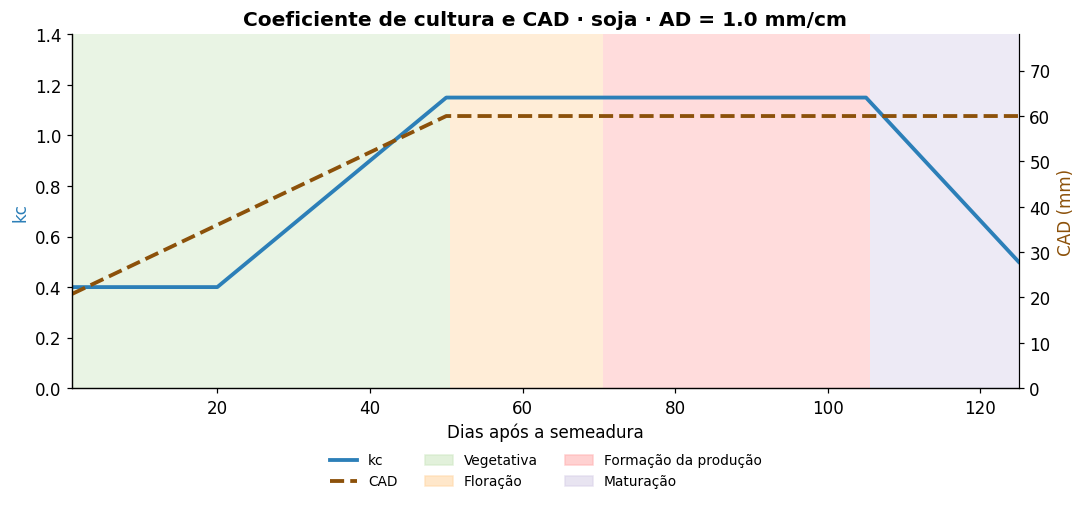

In [6]:
def sombrear_fases(ax, eixo='das'):
    """Pinta o fundo do gráfico com as fases da cultura."""
    inicio = 0
    for i, fim in enumerate(LIMITES):
        if eixo == 'das':
            a, b = inicio + 0.5, fim + 0.5
        else:
            a = data_sem + pd.Timedelta(days=int(inicio))
            b = data_sem + pd.Timedelta(days=int(fim))
        ax.axvspan(a, b, color=CORES_FASE[i], alpha=0.45, lw=0)
        inicio = fim


legenda_fases = [Patch(color=c, alpha=0.6, label=f) for c, f in zip(CORES_FASE, FASES)]

fig, ax1 = plt.subplots(figsize=(10, 4.8))
sombrear_fases(ax1)
ax1.plot(dia['DAS'], dia['kc'], color='#2c7fb8', lw=2.5, label='kc')
ax1.set_ylabel('kc', color='#2c7fb8')
ax1.set_ylim(0, 1.4)
ax1.set_xlabel('Dias após a semeadura')

ax2 = ax1.twinx()
ax2.spines['right'].set_visible(True)
ax2.plot(dia['DAS'], dia['CAD'], color='#8c510a', lw=2.5, ls='--', label='CAD')
ax2.set_ylabel('CAD (mm)', color='#8c510a')
ax2.set_ylim(0, AD_SOLO * p['Zmax'] * 100 * 1.3)

ax1.set_xlim(1, CICLO)
ax1.set_title(f'Coeficiente de cultura e CAD · {CULTURA} · AD = {AD_SOLO} mm/cm',
              fontweight='bold')
linhas = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
ax1.legend(handles=linhas + legenda_fases, frameon=False, ncol=3, fontsize=9,
           loc='upper center', bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
salvar(fig, 'aula03_kc_cad.png')
plt.show()

# 5. Agregação decendial
___

Os decêndios são os do calendário: dias 1 a 10, 11 a 20 e 21 ao fim do mês. Como a semeadura e a colheita raramente coincidem com o início ou o fim de um decêndio, os decêndios das pontas têm menos dias (ND).

Cada decêndio é atribuído à fase em que está o seu **dia central**. ETo e ETc são somadas dia a dia, então o kc variável dentro do decêndio é respeitado.

In [7]:
dia['decendio'] = np.minimum((dia.index.day - 1) // 10, 2) + 1
chave = [dia.index.year, dia.index.month, dia['decendio']]

dec = dia.groupby(chave).agg(
    inicio=('DAS', lambda s: s.index.min()),
    ND=('DAS', 'size'),
    DAS_meio=('DAS', 'median'),
    Tmed=('Tmed', 'mean'),
    Qg=('Qg', 'mean'),
    Qo=('Qo', 'mean'),
    N=('N', 'mean'),
    Chuva=('Chuva', 'sum'),
    ETo=('ETo', 'sum'),
    ETc=('ETc', 'sum'),
    CAD=('CAD', 'mean'),
).reset_index(drop=True)

dec['fase'] = np.searchsorted(LIMITES, dec['DAS_meio'], side='left')
dec['rotulo'] = dec['inicio'].dt.strftime('%d/%m')
dec.drop(columns='inicio').round(2)

,ND,DAS_meio,Tmed,Qg,Qo,N,Chuva,ETo,ETc,CAD,fase,rotulo
0,10,5.5,23.29,16.48,36.73,12.40,63.01,37.58,15.03,24.40,0,01/10
1,10,15.5,24.02,17.90,38.34,12.65,32.92,44.29,17.72,32.40,0,11/10
2,11,26.0,23.71,15.01,39.78,12.89,259.90,38.12,20.03,40.80,0,21/10
3,10,36.5,22.87,20.27,40.98,13.10,188.82,43.37,35.85,49.20,0,01/11
4,10,46.5,26.41,18.79,41.86,13.28,84.78,47.29,50.02,57.12,0,11/11
5,10,56.5,24.40,16.85,42.52,13.42,111.74,36.73,42.24,60.00,1,21/11
6,10,66.5,25.93,19.14,42.96,13.52,68.38,41.49,47.71,60.00,1,01/12
7,10,76.5,27.58,26.65,43.20,13.57,35.15,59.32,68.22,60.00,2,11/12
8,11,87.0,24.97,23.03,43.22,13.56,47.26,53.16,61.13,60.00,2,21/12
9,10,97.5,27.61,26.18,43.02,13.50,43.05,59.75,68.71,60.00,2,01/01


## 5.1 Figura: condições meteorológicas da safra

Figura salva em: figuras/aula03_meteorologia_safra.png


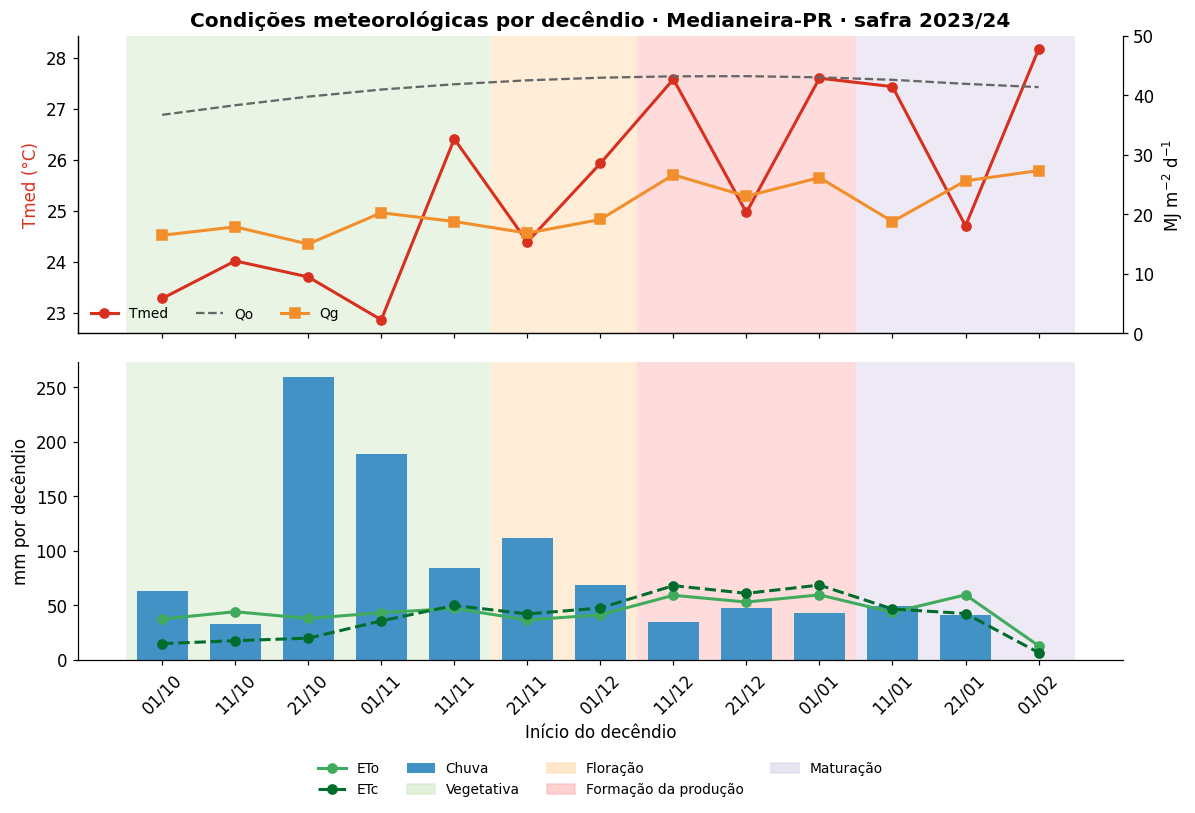

Chuva total: 1025 mm  |  ETo: 578 mm  |  ETc: 523 mm


In [8]:
x = np.arange(len(dec))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)


def sombrear_decendios(ax):
    for i, f in enumerate(dec['fase']):
        ax.axvspan(i - 0.5, i + 0.5, color=CORES_FASE[f], alpha=0.45, lw=0)


# Temperatura e radiação
sombrear_decendios(ax1)
ax1.plot(x, dec['Tmed'], 'o-', color='#d7301f', lw=2, label='Tmed')
ax1.set_ylabel('Tmed (°C)', color='#d7301f')
ax1b = ax1.twinx()
ax1b.spines['right'].set_visible(True)
ax1b.plot(x, dec['Qo'], '--', color='0.4', lw=1.5, label='Qo')
ax1b.plot(x, dec['Qg'], 's-', color='#f28e2b', lw=2, label='Qg')
ax1b.set_ylabel('MJ m$^{-2}$ d$^{-1}$')
ax1b.set_ylim(0, 50)
ax1.set_title(f'Condições meteorológicas por decêndio · {NOME_LOCAL} · '
              f'safra {data_sem:%Y}/{data_col:%y}', fontweight='bold')
h = ax1.get_legend_handles_labels()[0] + ax1b.get_legend_handles_labels()[0]
ax1.legend(handles=h, frameon=False, ncol=3, loc='lower left', fontsize=9)

# Chuva e ETo
sombrear_decendios(ax2)
ax2.bar(x, dec['Chuva'], color='#4292c6', width=0.7, label='Chuva')
ax2.plot(x, dec['ETo'], 'o-', color='#41ab5d', lw=2, label='ETo')
ax2.plot(x, dec['ETc'], 'o--', color='#006d2c', lw=2, label='ETc')
ax2.set_ylabel('mm por decêndio')
ax2.set_xticks(x)
ax2.set_xticklabels(dec['rotulo'], rotation=45)
ax2.set_xlabel('Início do decêndio')
ax2.legend(handles=ax2.get_legend_handles_labels()[0] + legenda_fases,
           frameon=False, ncol=4, fontsize=9, loc='upper center',
           bbox_to_anchor=(0.5, -0.3))

plt.tight_layout()
salvar(fig, 'aula03_meteorologia_safra.png')
plt.show()

print(f'Chuva total: {dec["Chuva"].sum():.0f} mm  |  ETo: {dec["ETo"].sum():.0f} mm  |  '
      f'ETc: {dec["ETc"].sum():.0f} mm')

# 6. Produtividade potencial (PPBp → PPf)
___

Para cada decêndio:

1. **Razão de insolação**, invertendo Angström-Prescott: n/N = (Qg/Qo − a)/b, com a = 0,29 · cos(φ) e b = 0,52, limitada entre 0 e 1.
2. **Correções de temperatura** cTc e cTn (C3 ou C4), limitadas a zero.
3. **PPBp** = PPBc + PPBn (kg MS ha⁻¹ d⁻¹).
4. **CR** = 0,6 se T < 20 °C e 0,5 se T ≥ 20 °C.
5. **Contribuição do decêndio** = PPBp · ND · CIAF · CR · Cc / (1 − 0,01 · U%).

A PPf é a soma das contribuições ao longo do ciclo.

In [9]:
def correcao_temperatura(T, rota):
    """Retorna (cTn, cTc) para culturas C3 ou C4 (Barbieri & Tuon, 1992)."""
    T = np.asarray(T, dtype=float)
    if rota == 'C4':
        alta = T >= 16.5
        cTn = np.where(alta, -1.064 + 0.173 * T - 0.0029 * T**2,
                             -4.16 + 0.4325 * T - 0.00725 * T**2)
        cTc = np.where(alta, -4.16 + 0.4325 * T - 0.00725 * T**2,
                             -9.32 + 0.865 * T - 0.0145 * T**2)
    else:
        cTn = -0.0425 + 0.035 * T + 0.00325 * T**2 - 0.0000925 * T**3
        cTc = 0.583 + 0.014 * T + 0.0013 * T**2 - 0.000037 * T**3
    return np.clip(cTn, 0, None), np.clip(cTc, 0, None)


a_ang = 0.29 * np.cos(np.radians(LAT))
b_ang = 0.52

dec['nN'] = ((dec['Qg'] / dec['Qo'] - a_ang) / b_ang).clip(0, 1)
dec['cTn'], dec['cTc'] = correcao_temperatura(dec['Tmed'], p['rota'])

dec['PPBc'] = (107.2 + 8.604 * dec['Qo']) * dec['cTc'] * dec['nN']
dec['PPBn'] = (31.7 + 5.234 * dec['Qo']) * dec['cTn'] * (1 - dec['nN'])
dec['PPBp'] = dec['PPBc'] + dec['PPBn']

dec['CR'] = np.where(dec['Tmed'] < 20, 0.6, 0.5)
dec['PPf_dec'] = (dec['PPBp'] * dec['ND'] * CIAF * dec['CR'] * p['Cc']
                  / (1 - 0.01 * p['U']))
dec['PPf_acum'] = dec['PPf_dec'].cumsum()

PPf = dec['PPf_dec'].sum()
print(f'PPf = {fmt(PPf)} kg/ha  ({PPf/60:.1f} sacas de 60 kg/ha)')
dec[['rotulo', 'ND', 'Tmed', 'nN', 'cTc', 'cTn', 'PPBc', 'PPBn', 'PPBp', 'CR', 'PPf_dec']].round(3)

PPf = 5.345 kg/ha  (89.1 sacas de 60 kg/ha)


,rotulo,ND,Tmed,nN,cTc,cTn,PPBc,PPBn,PPBp,CR,PPf_dec
0,01/10,10,23.286,0.359,1.147,1.367,174.190,196.205,370.395,0.5,363.154
1,11/10,10,24.023,0.394,1.157,1.392,198.966,196.051,395.016,0.5,387.295
2,21/10,11,23.709,0.221,1.153,1.381,114.641,258.104,372.745,0.5,402.005
3,01/11,10,22.868,0.447,1.141,1.351,234.438,183.914,418.352,0.5,410.175
4,11/11,10,26.415,0.359,1.178,1.445,197.696,232.261,429.957,0.5,421.552
5,21/11,10,24.396,0.258,1.161,1.403,141.490,264.757,406.246,0.5,398.305
6,01/12,10,25.935,0.352,1.175,1.438,197.484,238.861,436.345,0.5,427.816
7,11/12,10,27.585,0.682,1.182,1.454,385.997,119.202,505.199,0.5,495.324
8,21/12,11,24.973,0.521,1.167,1.418,291.119,175.292,466.411,0.5,503.024
9,01/01,10,27.606,0.666,1.182,1.454,375.621,124.865,500.486,0.5,490.703


## 6.1 Figura: PPBp por decêndio e PPf acumulada

Figura salva em: figuras/aula03_ppbp_ppf.png


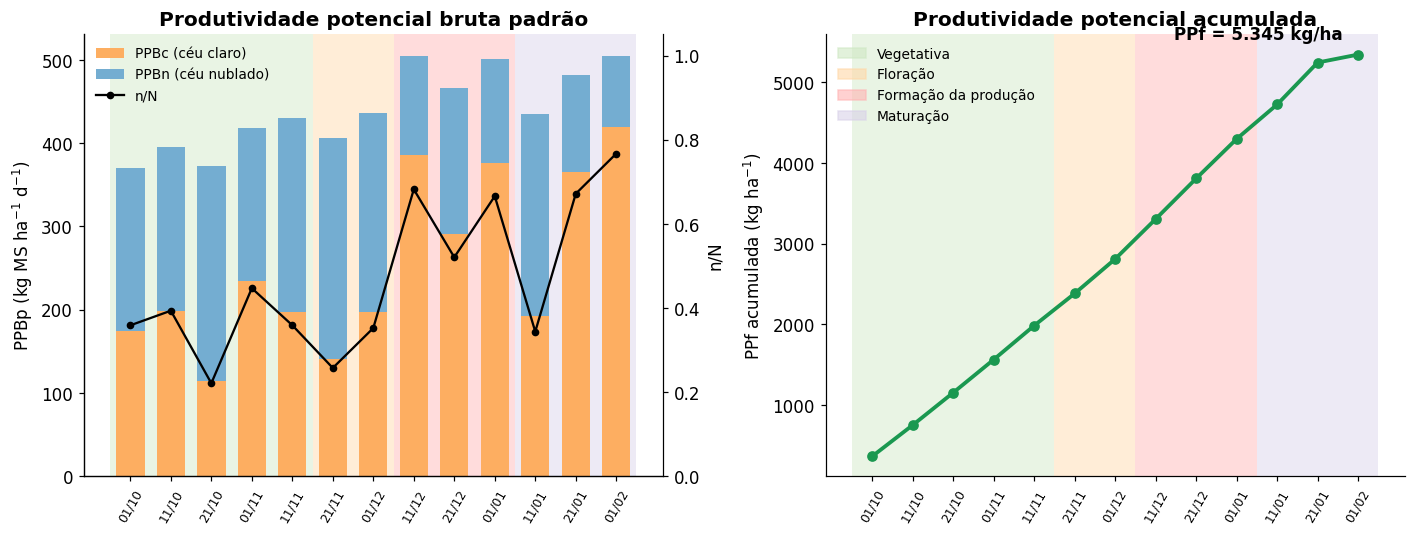

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# PPBp diária: céu claro + céu nublado
sombrear_decendios(ax1)
ax1.bar(x, dec['PPBc'], color='#fdae61', width=0.7, label='PPBc (céu claro)')
ax1.bar(x, dec['PPBn'], bottom=dec['PPBc'], color='#74add1', width=0.7,
        label='PPBn (céu nublado)')
ax1.set_ylabel('PPBp (kg MS ha$^{-1}$ d$^{-1}$)')
ax1b = ax1.twinx()
ax1b.spines['right'].set_visible(True)
ax1b.plot(x, dec['nN'], 'ko-', lw=1.5, ms=4, label='n/N')
ax1b.set_ylim(0, 1.05)
ax1b.set_ylabel('n/N')
ax1.set_xticks(x)
ax1.set_xticklabels(dec['rotulo'], rotation=60, fontsize=8)
ax1.set_title('Produtividade potencial bruta padrão', fontweight='bold')
h = ax1.get_legend_handles_labels()[0] + ax1b.get_legend_handles_labels()[0]
ax1.legend(handles=h, frameon=False, fontsize=9, loc='upper left')

# PPf acumulada
sombrear_decendios(ax2)
ax2.plot(x, dec['PPf_acum'], 'o-', color='#1a9850', lw=2.5)
ax2.annotate(f'PPf = {fmt(PPf)} kg/ha',
             (x[-1], PPf), xytext=(-10, 10), textcoords='offset points',
             ha='right', fontweight='bold')
ax2.set_ylabel('PPf acumulada (kg ha$^{-1}$)')
ax2.set_xticks(x)
ax2.set_xticklabels(dec['rotulo'], rotation=60, fontsize=8)
ax2.set_title('Produtividade potencial acumulada', fontweight='bold')
ax2.legend(handles=legenda_fases, frameon=False, fontsize=9, loc='upper left')

plt.tight_layout()
salvar(fig, 'aula03_ppbp_ppf.png')
plt.show()

# 7. Balanço hídrico da cultura
___

Balanço sequencial decendial de Thornthwaite & Mather com `amp.balanco_hidrico_cultura`, usando a CAD de cada decêndio (crescente com a raiz). O solo é considerado na capacidade de campo na semeadura.

Figura salva em: figuras/aula03_balanco_hidrico.png


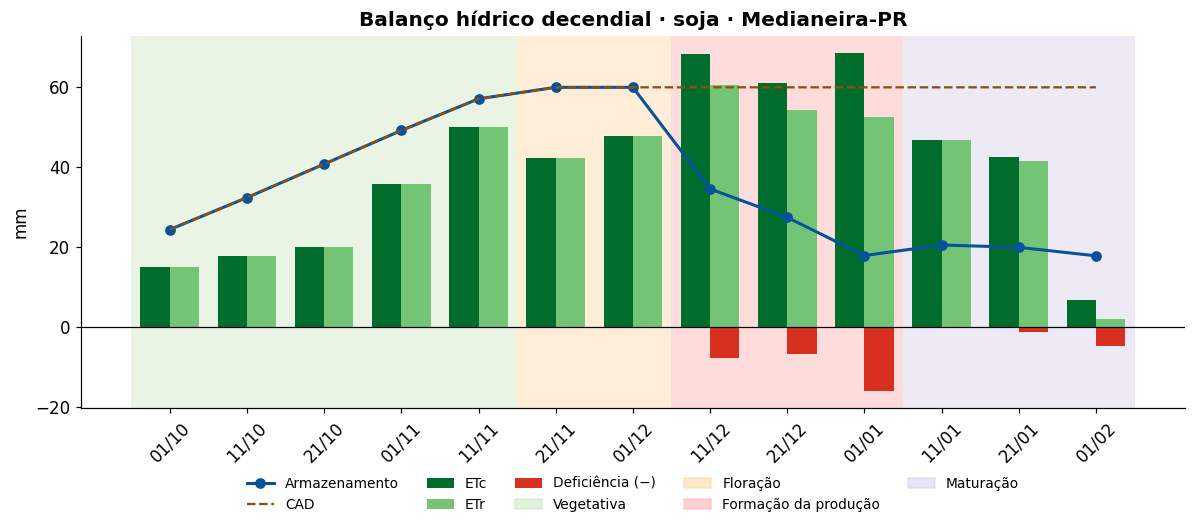

,rotulo,fase,Chuva,ETc,CAD,ARM,ETr,DEF
0,01/10,0,63.0,15.0,24.4,24.4,15.0,0.0
1,11/10,0,32.9,17.7,32.4,32.4,17.7,0.0
2,21/10,0,259.9,20.0,40.8,40.8,20.0,0.0
3,01/11,0,188.8,35.9,49.2,49.2,35.9,0.0
4,11/11,0,84.8,50.0,57.1,57.1,50.0,0.0
5,21/11,1,111.7,42.2,60.0,60.0,42.2,0.0
6,01/12,1,68.4,47.7,60.0,60.0,47.7,0.0
7,11/12,2,35.2,68.2,60.0,34.6,60.6,7.6
8,21/12,2,47.3,61.1,60.0,27.4,54.4,6.7
9,01/01,2,43.0,68.7,60.0,17.9,52.6,16.1


In [11]:
bh = amp.balanco_hidrico_cultura(dec[['Chuva', 'ETc', 'CAD']])
dec['ETr'] = bh['ETR'].values
dec['DEF'] = bh['DEF'].values
dec['ARM'] = bh['ARM'].values

fig, ax = plt.subplots(figsize=(11, 5))
sombrear_decendios(ax)
largura = 0.38
ax.bar(x - largura/2, dec['ETc'], width=largura, color='#006d2c', label='ETc')
ax.bar(x + largura/2, dec['ETr'], width=largura, color='#74c476', label='ETr')
ax.bar(x + largura/2, -dec['DEF'], width=largura, color='#d7301f', label='Deficiência (−)')
ax.plot(x, dec['ARM'], 'o-', color='#08519c', lw=2, label='Armazenamento')
ax.plot(x, dec['CAD'], '--', color='#8c510a', lw=1.5, label='CAD')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('mm')
ax.set_xticks(x)
ax.set_xticklabels(dec['rotulo'], rotation=45)
ax.set_title(f'Balanço hídrico decendial · {CULTURA} · {NOME_LOCAL}', fontweight='bold')
ax.legend(handles=ax.get_legend_handles_labels()[0] + legenda_fases,
          frameon=False, ncol=5, fontsize=9, loc='upper center',
          bbox_to_anchor=(0.5, -0.15))

plt.tight_layout()
salvar(fig, 'aula03_balanco_hidrico.png')
plt.show()

dec[['rotulo', 'fase', 'Chuva', 'ETc', 'CAD', 'ARM', 'ETr', 'DEF']].round(1)

# 8. Produtividade atingível pelo produtório
___

Para cada fase *i*, com ETr e ETc somadas nos decêndios da fase:

$$f_i = 1 - k_{y,i} \cdot \left(1 - \frac{ETr_i}{ETc_i}\right)$$

A penalização é aplicada **em sequência**: a PA ao fim de uma fase é o ponto de partida da fase seguinte.

$$PA_0 = PPf \qquad PA_i = PA_{i-1} \cdot f_i \qquad \text{Perda}_i = PA_{i-1} - PA_i$$

In [12]:
fases = (dec.groupby('fase')[['Chuva', 'ETc', 'ETr', 'DEF']].sum()
         .reindex(range(4), fill_value=0))
fases.index = FASES
fases['ETr/ETc'] = fases['ETr'] / fases['ETc']
fases['ky'] = p['ky']
fases['fator'] = (1 - fases['ky'] * (1 - fases['ETr/ETc'])).clip(lower=0)

pa = [PPf]
for f in fases['fator']:
    pa.append(pa[-1] * f)
fases['PA inicial'] = pa[:-1]
fases['PA final'] = pa[1:]
fases['Perda (kg/ha)'] = fases['PA inicial'] - fases['PA final']
fases['Perda (% da PPf)'] = 100 * fases['Perda (kg/ha)'] / PPf

PA = pa[-1]
EC = PA / PPf

# Comparação: penalização em etapa única com o ky do ciclo
razao_ciclo = fases['ETr'].sum() / fases['ETc'].sum()
PA_unica = PPf * max(0, 1 - p['ky_ciclo'] * (1 - razao_ciclo))

print(f'PPf = {fmt(PPf)} kg/ha')
print(f'PA (produtório) = {fmt(PA)} kg/ha  →  EC = {EC:.3f}')
print(f'PA (etapa única, ky = {p["ky_ciclo"]}) = {fmt(PA_unica)} kg/ha  →  EC = {PA_unica/PPf:.3f}')
fases.round(3)

PPf = 5.345 kg/ha
PA (produtório) = 4.522 kg/ha  →  EC = 0.846
PA (etapa única, ky = 0.85) = 5.030 kg/ha  →  EC = 0.941


,Chuva,ETc,ETr,DEF,ETr/ETc,ky,fator,PA inicial,PA final,Perda (kg/ha),Perda (% da PPf)
Vegetativa,629.433,138.659,138.659,0.000,1.000,0.2,1.000,5345.402,5345.402,0.00,0.000
Floração,180.116,89.951,89.951,0.000,1.000,0.8,1.000,5345.402,5345.402,0.00,0.000
Formação da produção,125.459,198.066,167.569,30.497,0.846,1.0,0.846,5345.402,4522.351,823.05,15.397
Maturação,90.300,96.141,90.367,5.774,0.940,0.0,1.000,4522.351,4522.351,0.00,0.000


## 8.1 Figura: redução da produtividade por fase

Figura salva em: figuras/aula03_reducao_por_fase.png


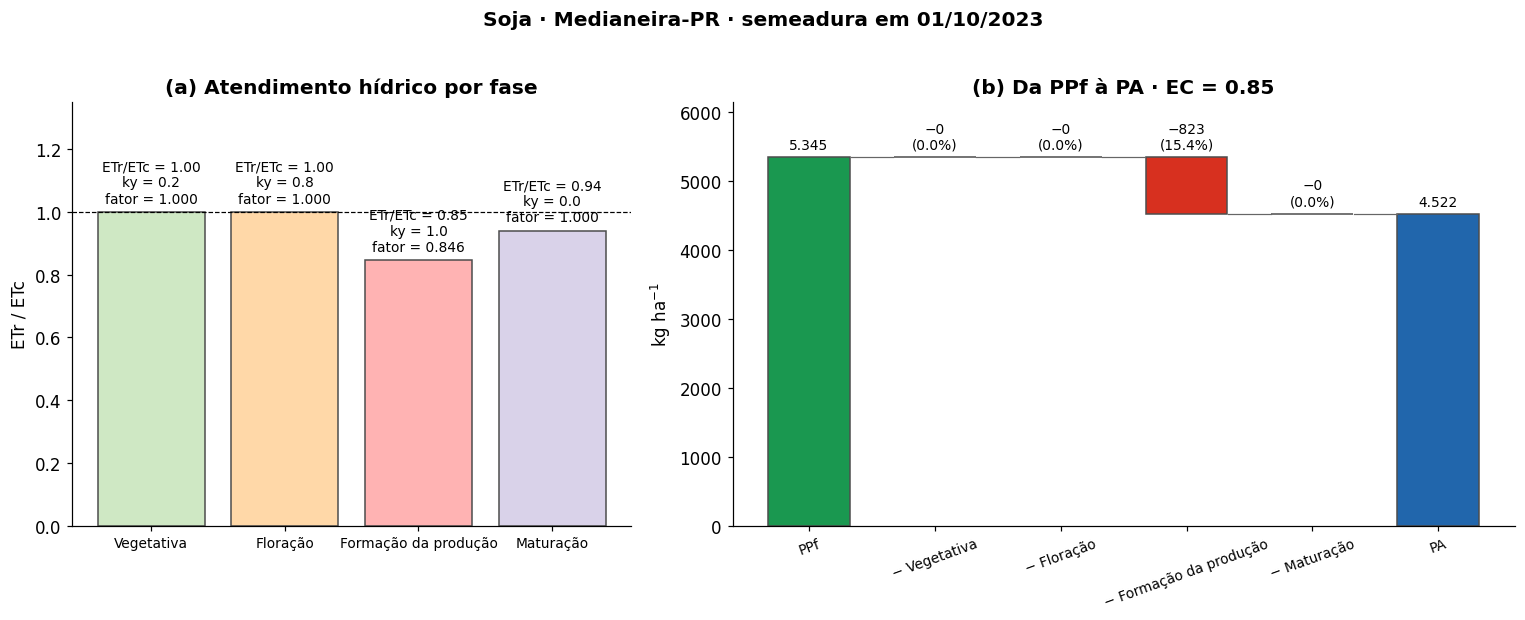

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5),
                               gridspec_kw={'width_ratios': [1, 1.4]})

# (a) Atendimento hídrico por fase
barras = ax1.bar(FASES, fases['ETr/ETc'], color=CORES_FASE, edgecolor='0.3')
ax1.axhline(1, color='black', lw=0.8, ls='--')
for b, (r, ky, f) in zip(barras, fases[['ETr/ETc', 'ky', 'fator']].values):
    ax1.text(b.get_x() + b.get_width()/2, r + 0.02,
             f'ETr/ETc = {r:.2f}\nky = {ky}\nfator = {f:.3f}',
             ha='center', va='bottom', fontsize=9)
ax1.set_ylim(0, 1.35)
ax1.set_ylabel('ETr / ETc')
ax1.set_title('(a) Atendimento hídrico por fase', fontweight='bold')
ax1.tick_params(axis='x', labelsize=9)

# (b) Cascata: PPf → perdas por fase → PA
rotulos = ['PPf'] + [f'− {f}' for f in FASES] + ['PA']
base, altura, cores = [], [], []
nivel = PPf
base.append(0); altura.append(PPf); cores.append('#1a9850')
for perda, cor in zip(fases['Perda (kg/ha)'], CORES_FASE):
    base.append(nivel - perda); altura.append(perda); cores.append('#d7301f')
    nivel -= perda
base.append(0); altura.append(PA); cores.append('#2166ac')

pos = np.arange(len(rotulos))
ax2.bar(pos, altura, bottom=base, color=cores, edgecolor='0.3', width=0.65)
for i in range(len(pos) - 1):                      # linhas de ligação
    topo = base[i] + altura[i] if i == 0 else base[i]
    ax2.plot([i + 0.33, i + 0.67], [topo, topo], color='0.4', lw=0.8)
for i, (b, h) in enumerate(zip(base, altura)):
    if i in (0, len(pos) - 1):
        txt = fmt(h)
    else:
        txt = f'−{fmt(h)}\n({100*h/PPf:.1f}%)'
    ax2.text(i, b + h + PPf * 0.015, txt, ha='center', va='bottom', fontsize=9)
ax2.set_xticks(pos)
ax2.set_xticklabels(rotulos, rotation=20, fontsize=9)
ax2.set_ylabel('kg ha$^{-1}$')
ax2.set_ylim(0, PPf * 1.15)
ax2.set_title(f'(b) Da PPf à PA · EC = {EC:.2f}', fontweight='bold')

fig.suptitle(f'{CULTURA.capitalize()} · {NOME_LOCAL} · semeadura em {data_sem:%d/%m/%Y}',
             fontweight='bold', y=1.02)
plt.tight_layout()
salvar(fig, 'aula03_reducao_por_fase.png')
plt.show()

# 9. Resumo da safra
___

In [14]:
resumo = pd.Series({
    'Local': NOME_LOCAL,
    'Cultura': f'{CULTURA} ({p["rota"]})',
    'Semeadura': f'{data_sem:%d/%m/%Y}',
    'Colheita': f'{data_col:%d/%m/%Y}',
    'Chuva no ciclo (mm)': round(dec['Chuva'].sum()),
    'ETc no ciclo (mm)': round(dec['ETc'].sum()),
    'ETr no ciclo (mm)': round(dec['ETr'].sum()),
    'Deficiência no ciclo (mm)': round(dec['DEF'].sum()),
    'PPf (kg/ha)': round(PPf),
    'PA, produtório (kg/ha)': round(PA),
    'PA, etapa única (kg/ha)': round(PA_unica),
    'EC, produtório': round(EC, 3),
    'Fase com maior perda': fases['Perda (kg/ha)'].idxmax(),
})
resumo.to_frame('Valor')

,Valor
Local,Medianeira-PR
Cultura,soja (C3)
Semeadura,01/10/2023
Colheita,02/02/2024
Chuva no ciclo (mm),1025
ETc no ciclo (mm),523
ETr no ciclo (mm),487
Deficiência no ciclo (mm),36
PPf (kg/ha),5345
"PA, produtório (kg/ha)",4522


## Para discutir

1. Em qual fase ocorreu a maior perda? Ela coincide com a fase de maior déficit hídrico em milímetros?
2. Por que a perda de uma fase com ETr/ETc alto pode ser maior do que a de outra fase com ETr/ETc baixo?
3. Compare a PA do produtório com a da etapa única. Em que situação as duas se aproximam?
4. Repita a simulação com a semeadura um mês antes e um mês depois. O que muda na PPf? E na EC?
5. Troque `AD_SOLO` para 0,6 (solo arenoso) e para 1,4 mm/cm. Qual fase é mais afetada?

## Referências

ALLEN, R. G. et al. **Crop evapotranspiration**. Rome: FAO, 1998. (Irrigation and Drainage Paper, 56).

BATTISTI, R. et al. Eficiência climática para as culturas da soja e do trigo no estado do Rio Grande do Sul em diferentes datas de semeadura. **Ciência Rural**, v. 43, n. 3, p. 390-396, 2013.

DOORENBOS, J.; KASSAM, A. H. **Yield response to water**. Rome: FAO, 1979. (Irrigation and Drainage Paper, 33).

XAVIER, A. C. et al. New improved Brazilian daily weather gridded data (1961–2020). **International Journal of Climatology**, v. 42, n. 16, p. 8390-8404, 2022.